In [33]:
%pip install anthropic python-dotenv pandas

Note: you may need to restart the kernel to use updated packages.


In [34]:
from dotenv import load_dotenv
from anthropic import Anthropic
import os
import pandas as pd
import json
from pathlib import Path

load_dotenv()

api_key = os.getenv("ANTHROPIC_API_KEY")
client = Anthropic(api_key=api_key)

print("API key loaded:", api_key is not None)

API key loaded: True


In [35]:
Path("data").mkdir(exist_ok=True)
Path("memory").mkdir(exist_ok=True)
Path("reports").mkdir(exist_ok=True)

print("Folders ready.")

Folders ready.


In [36]:
import pandas as pd
import numpy as np
from pathlib import Path

# make sure data folder exists
Path("data").mkdir(exist_ok=True)

# time vector (0–12 hours)
time = np.linspace(0, 12, 100)

# simulate biomass growth (logistic-like)
biomass = 0.2 + 6 / (1 + np.exp(-0.8*(time-6)))

# simulate DO drop as cells grow
DO = 95 - (biomass * 10) + np.random.normal(0, 2, size=len(time))
DO = np.clip(DO, 5, 100)

# simulate slight pH drift
pH = 6.8 - 0.3*(time/12) + np.random.normal(0, 0.02, size=len(time))

# simulate glucose consumption
glucose = 20 * np.exp(-0.25*time)

df = pd.DataFrame({
    "time": time,
    "biomass": biomass,
    "DO": DO,
    "pH": pH,
    "glucose": glucose
})

# save dataset
df.to_csv("data/run_001.csv", index=False)

df.head()

,time,biomass,DO,pH,glucose
0,0.000000,0.248975,93.145116,6.774169,20.000000
1,0.121212,0.253918,93.100042,6.752544,19.403030
2,0.242424,0.259354,88.721777,6.775849,18.823879
3,0.363636,0.265332,96.670651,6.776833,18.262014
4,0.484848,0.271904,92.960724,6.771254,17.716921


In [37]:
file_path = "data/run_001.csv"
df = pd.read_csv(file_path)

df.head()

,time,biomass,DO,pH,glucose
0,0.000000,0.248975,93.145116,6.774169,20.000000
1,0.121212,0.253918,93.100042,6.752544,19.403030
2,0.242424,0.259354,88.721777,6.775849,18.823879
3,0.363636,0.265332,96.670651,6.776833,18.262014
4,0.484848,0.271904,92.960724,6.771254,17.716921


In [38]:
df = pd.read_csv(file_path)

# remove rows without time
df = df.dropna(subset=["time"])

# ensure chronological order
df = df.sort_values("time").reset_index(drop=True)

In [39]:
required_for_time_series = ["time"]

if not all(col in df.columns for col in required_for_time_series):
    raise ValueError("Dataset must contain a 'time' column.")

In [40]:
metadata = {
    "experiment_id": "run_001",
    "date": "2026-03-14",
    "organism": "unknown",
    "reactor_type": "stirred tank",
    "notes": "No extra notes yet."
}

In [41]:
def extract_features(df):
    features = {}

    if "time" in df.columns:
        features["duration_h"] = float(df["time"].max())

    if "DO" in df.columns:
        features["min_do"] = float(df["DO"].min())
        features["time_min_do"] = float(df.loc[df["DO"].idxmin(), "time"])

    if "biomass" in df.columns:
        features["max_biomass"] = float(df["biomass"].max())
        features["final_biomass"] = float(df["biomass"].iloc[-1])

    if "pH" in df.columns:
        features["min_pH"] = float(df["pH"].min())
        features["max_pH"] = float(df["pH"].max())
        features["final_pH"] = float(df["pH"].iloc[-1])

    return features

features = extract_features(df)
features

{'duration_h': 12.0,
 'min_do': 28.78657100703806,
 'time_min_do': 11.030303030303031,
 'max_biomass': 6.151024573081041,
 'final_biomass': 6.151024573081041,
 'min_pH': 6.482543157304313,
 'max_pH': 6.804609713427489,
 'final_pH': 6.489985337835257}

In [26]:
def extract_features(df):
    features = {}

    if "time" in df.columns:
        features["start_time_h"] = float(df["time"].iloc[0])
        features["end_time_h"] = float(df["time"].iloc[-1])
        features["duration_h"] = float(df["time"].iloc[-1] - df["time"].iloc[0])

    if "DO" in df.columns:
        features["initial_do"] = float(df["DO"].iloc[0])
        features["min_do"] = float(df["DO"].min())
        features["final_do"] = float(df["DO"].iloc[-1])
        features["time_min_do"] = float(df.loc[df["DO"].idxmin(), "time"])
        features["do_drop"] = float(df["DO"].iloc[0] - df["DO"].min())

    if "biomass" in df.columns:
        features["initial_biomass"] = float(df["biomass"].iloc[0])
        features["max_biomass"] = float(df["biomass"].max())
        features["final_biomass"] = float(df["biomass"].iloc[-1])
        features["biomass_increase"] = float(df["biomass"].iloc[-1] - df["biomass"].iloc[0])

    if "pH" in df.columns:
        features["initial_pH"] = float(df["pH"].iloc[0])
        features["min_pH"] = float(df["pH"].min())
        features["max_pH"] = float(df["pH"].max())
        features["final_pH"] = float(df["pH"].iloc[-1])
        features["pH_range"] = float(df["pH"].max() - df["pH"].min())

    if "glucose" in df.columns:
        features["initial_glucose"] = float(df["glucose"].iloc[0])
        features["final_glucose"] = float(df["glucose"].iloc[-1])
        features["glucose_consumed"] = float(df["glucose"].iloc[0] - df["glucose"].iloc[-1])

    return features

features = extract_features(df)
features


{'start_time_h': 0.0,
 'end_time_h': 12.0,
 'duration_h': 12.0,
 'initial_do': 92.27379169279418,
 'min_do': 28.510280488749807,
 'final_do': 33.14128786204126,
 'time_min_do': 10.666666666666668,
 'do_drop': 63.76351120404437,
 'initial_biomass': 0.2489754269189593,
 'max_biomass': 6.151024573081041,
 'final_biomass': 6.151024573081041,
 'biomass_increase': 5.902049146162081,
 'initial_pH': 6.79562516497666,
 'min_pH': 6.490762958801663,
 'max_pH': 6.8184234311612,
 'final_pH': 6.490762958801663,
 'pH_range': 0.3276604723595371,
 'initial_glucose': 20.0,
 'final_glucose': 0.9957413673572788,
 'glucose_consumed': 19.00425863264272}

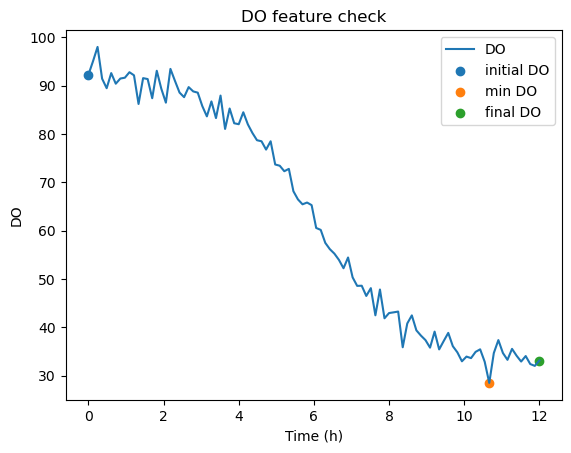

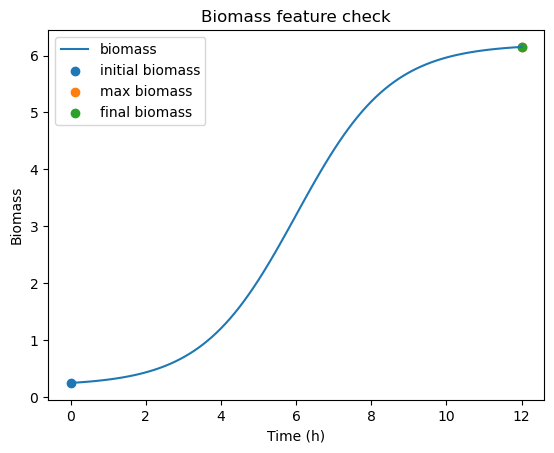

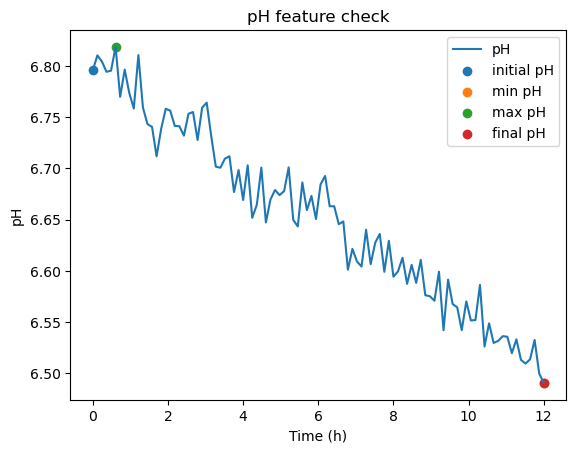

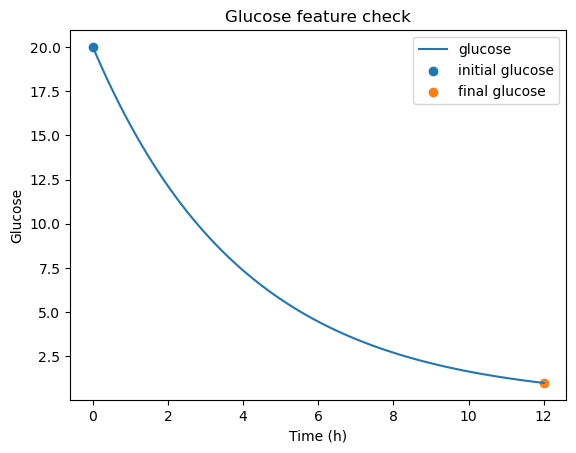

In [27]:
import matplotlib.pyplot as plt

def plot_feature_checks(df, features):

    if "DO" in df.columns:
        plt.figure()
        plt.plot(df["time"], df["DO"], label="DO")

        plt.scatter(features["start_time_h"], features["initial_do"], label="initial DO")
        plt.scatter(features["time_min_do"], features["min_do"], label="min DO")
        plt.scatter(features["end_time_h"], features["final_do"], label="final DO")

        plt.xlabel("Time (h)")
        plt.ylabel("DO")
        plt.legend()
        plt.title("DO feature check")
        plt.show()


    if "biomass" in df.columns:
        plt.figure()
        plt.plot(df["time"], df["biomass"], label="biomass")

        plt.scatter(features["start_time_h"], features["initial_biomass"], label="initial biomass")
        plt.scatter(df.loc[df["biomass"].idxmax(), "time"], features["max_biomass"], label="max biomass")
        plt.scatter(features["end_time_h"], features["final_biomass"], label="final biomass")

        plt.xlabel("Time (h)")
        plt.ylabel("Biomass")
        plt.legend()
        plt.title("Biomass feature check")
        plt.show()


    if "pH" in df.columns:
        plt.figure()
        plt.plot(df["time"], df["pH"], label="pH")

        plt.scatter(features["start_time_h"], features["initial_pH"], label="initial pH")
        plt.scatter(df.loc[df["pH"].idxmin(), "time"], features["min_pH"], label="min pH")
        plt.scatter(df.loc[df["pH"].idxmax(), "time"], features["max_pH"], label="max pH")
        plt.scatter(features["end_time_h"], features["final_pH"], label="final pH")

        plt.xlabel("Time (h)")
        plt.ylabel("pH")
        plt.legend()
        plt.title("pH feature check")
        plt.show()


    if "glucose" in df.columns:
        plt.figure()
        plt.plot(df["time"], df["glucose"], label="glucose")

        plt.scatter(features["start_time_h"], features["initial_glucose"], label="initial glucose")
        plt.scatter(features["end_time_h"], features["final_glucose"], label="final glucose")

        plt.xlabel("Time (h)")
        plt.ylabel("Glucose")
        plt.legend()
        plt.title("Glucose feature check")
        plt.show()
        
features = extract_features(df)
plot_feature_checks(df, features)

In [30]:
def detect_events(df):
    events = []

    # Ensure time ordering if present
    if "time" in df.columns:
        df = df.sort_values("time")

    # --- Dissolved oxygen ---
    if "DO" in df.columns:
        do_series = df["DO"].dropna()

        if not do_series.empty:
            min_do = do_series.min()

            if min_do < 20:
                events.append(
                    f"Low dissolved oxygen detected (minimum DO = {min_do:.2f})."
                )

    # --- Biomass plateau ---
    if "biomass" in df.columns:
        biomass = df["biomass"].dropna()

        if len(biomass) >= 5:
            recent = biomass.tail(5)

            if (recent.max() - recent.min()) < 0.05:
                events.append(
                    "Biomass may be approaching a plateau near the end of the run."
                )

    # --- pH drift ---
    if "pH" in df.columns:
        ph_series = df["pH"].dropna()

        if not ph_series.empty:
            ph_range = ph_series.max() - ph_series.min()

            if ph_range > 0.5:
                events.append(
                    f"Noticeable pH drift detected (range = {ph_range:.2f})."
                )

    return events


events = detect_events(df)
events

['Biomass may be approaching a plateau near the end of the run.']

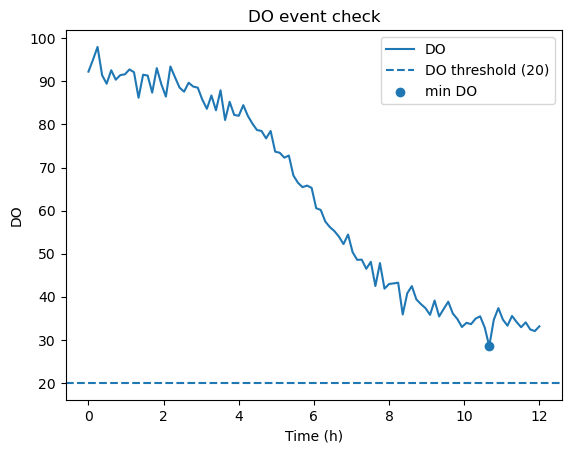

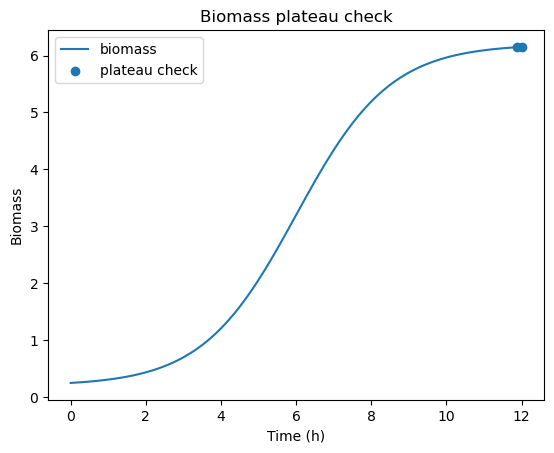

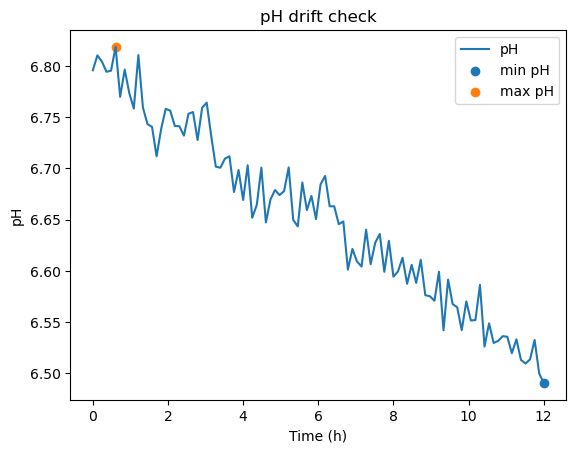

['Biomass may be approaching a plateau near the end of the run.']


In [29]:
import matplotlib.pyplot as plt

def plot_event_checks(df):

    if "DO" in df.columns:
        plt.figure()
        plt.plot(df["time"], df["DO"], label="DO")
        plt.axhline(20, linestyle="--", label="DO threshold (20)")

        min_idx = df["DO"].idxmin()
        plt.scatter(df.loc[min_idx, "time"], df.loc[min_idx, "DO"], label="min DO")

        plt.xlabel("Time (h)")
        plt.ylabel("DO")
        plt.title("DO event check")
        plt.legend()
        plt.show()


    if "biomass" in df.columns and len(df["biomass"]) > 2:
        plt.figure()
        plt.plot(df["time"], df["biomass"], label="biomass")

        plt.scatter(df["time"].iloc[-2:], df["biomass"].iloc[-2:], label="plateau check")

        plt.xlabel("Time (h)")
        plt.ylabel("Biomass")
        plt.title("Biomass plateau check")
        plt.legend()
        plt.show()


    if "pH" in df.columns:
        plt.figure()
        plt.plot(df["time"], df["pH"], label="pH")

        min_idx = df["pH"].idxmin()
        max_idx = df["pH"].idxmax()

        plt.scatter(df.loc[min_idx, "time"], df.loc[min_idx, "pH"], label="min pH")
        plt.scatter(df.loc[max_idx, "time"], df.loc[max_idx, "pH"], label="max pH")

        plt.xlabel("Time (h)")
        plt.ylabel("pH")
        plt.title("pH drift check")
        plt.legend()
        plt.show()
    
events = detect_events(df)
plot_event_checks(df)

print(events)

In [11]:
def build_prompt(metadata, features, events):
    return f"""
You are helping interpret a fermentation experiment.

Metadata:
{json.dumps(metadata, indent=2)}

Extracted features:
{json.dumps(features, indent=2)}

Detected events:
{json.dumps(events, indent=2)}

Please provide:
1. A short scientific summary of what happened in the run.
2. Two or three possible biological or process explanations.
3. Three suggested follow-up checks or next steps.

Be careful not to overclaim. If uncertain, say so.
"""
prompt = build_prompt(metadata, features, events)
print(prompt)


You are helping interpret a fermentation experiment.

Metadata:
{
  "experiment_id": "run_001",
  "date": "2026-03-14",
  "organism": "unknown",
  "reactor_type": "stirred tank",
  "notes": "No extra notes yet."
}

Extracted features:
{
  "start_time_h": 0.0,
  "end_time_h": 12.0,
  "duration_h": 12.0,
  "initial_do": 92.30280302900071,
  "min_do": 30.120065853848,
  "final_do": 32.41971836684037,
  "time_min_do": 10.666666666666668,
  "do_drop": 62.18273717515271,
  "initial_biomass": 0.2489754269189593,
  "max_biomass": 6.151024573081041,
  "final_biomass": 6.151024573081041,
  "biomass_increase": 5.902049146162081,
  "initial_pH": 6.789148890817545,
  "min_pH": 6.475183828981292,
  "max_pH": 6.8322784790322855,
  "final_pH": 6.475183828981292,
  "pH_range": 0.3570946500509935,
  "initial_glucose": 20.0,
  "final_glucose": 0.9957413673572788,
  "glucose_consumed": 19.00425863264272
}

Detected events:
[
  "Biomass may be approaching a plateau near the end of the run."
]

Please prov

In [12]:
message = client.messages.create(
    model="claude-sonnet-4-0",
    max_tokens=500,
    messages=[
        {"role": "user", "content": prompt}
    ]
)

ai_response = message.content[0].text
print(ai_response)

## Scientific Summary

This 12-hour fermentation run shows characteristic aerobic growth behavior. The culture consumed 95% of the initial glucose (19.0 g/L), achieved a ~25-fold biomass increase (0.25 to 6.15 g/L), and showed strong oxygen demand with dissolved oxygen dropping from 92% to a minimum of 30% around hour 10.7. The pH remained relatively stable with a modest decline from 6.79 to 6.48. Growth appeared to plateau toward the end, coinciding with near-complete glucose depletion.

## Possible Biological/Process Explanations

1. **Glucose limitation-induced stationary phase**: The culture likely entered stationary phase due to glucose depletion (only 1.0 g/L remaining). The timing of the biomass plateau aligns with substrate exhaustion, which is typical for batch fermentation without feeding.

2. **Oxygen transfer limitation**: The sustained low DO levels (30-32%) in the final hours suggest the culture's oxygen demand may have exceeded the reactor's transfer capacity, potentiall

In [13]:
memory_record = {
    "experiment_id": metadata["experiment_id"],
    "date": metadata["date"],
    "metadata": metadata,
    "features": features,
    "events": events,
    "ai_summary": ai_response
}

memory_file = f"memory/{metadata['experiment_id']}.json"

with open(memory_file, "w") as f:
    json.dump(memory_record, f, indent=2)

print(f"Memory saved to {memory_file}")

Memory saved to memory/run_001.json


In [14]:
report_file = f"reports/{metadata['experiment_id']}_report.txt"

with open(report_file, "w") as f:
    f.write(ai_response)

print(f"Report saved to {report_file}")

Report saved to reports/run_001_report.txt
